# Exploratory data analysis

This notebook loads the French motor third-party liability data, applies the cleaning rules in `pricing.data`, and looks at the three things a pricing model has to deal with: exposure, claim counts and claim amounts. It then looks at how observed claim frequency varies with each rating factor, one factor at a time.

Every frequency in this notebook is exposure-weighted: total claims divided by total policy-years, not an average of per-policy rates.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from pricing.data import build_policy_table, data_quality_summary, load_raw, split_train_test
from pricing.evaluation import one_way_table
from pricing.plots import SERIES, plot_one_way, plot_severity_distribution, save, set_style

set_style()
pl.Config.set_tbl_rows(25)
pl.Config.set_float_precision(4)

polars.config.Config

## 1. Load the data

`load_raw` downloads both tables from OpenML on the first run and caches them as parquet in `data/raw/`. The frequency table has one row per policy. The severity table has one row per claim, with only an ID and an amount.

In [2]:
freq_raw, sev_raw = load_raw()
print(freq_raw.shape, sev_raw.shape)
freq_raw.head()

(678013, 12) (26639, 2)


IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
f64,i64,f64,cat,i64,i64,i64,i64,cat,str,i64,cat
1.0000,1,0.1000,"""D""",5,0,55,50,"""B12""","""'Regular'""",1217,"""R82"""
3.0000,1,0.7700,"""D""",5,0,55,50,"""B12""","""'Regular'""",1217,"""R82"""
5.0000,1,0.7500,"""B""",6,2,52,50,"""B12""","""'Diesel'""",54,"""R22"""
10.0000,1,0.0900,"""B""",7,0,46,50,"""B12""","""'Diesel'""",76,"""R72"""
11.0000,1,0.8400,"""B""",7,0,46,50,"""B12""","""'Diesel'""",76,"""R72"""


## 2. Data quality

Before cleaning, count the problems the cleaning rules deal with.

In [3]:
pl.DataFrame(
    {"check": list(q := data_quality_summary(freq_raw, sev_raw)), "count": list(q.values())}
)

check,count
str,i64
"""policies""",678013
"""claim_rows""",26639
"""claim_nb_above_cap""",9
"""exposure_above_cap""",1224
"""policies_with_claims_but_no_se…",9116
"""claims_with_no_severity""",9657
"""severity_count_mismatch""",1
"""severity_policies_not_in_freq""",6


What each rule does, and why:

- **Claims with no cost recorded.** 9,116 policies (9,657 claims) have a claim count in the frequency table but no rows in the severity table. Their claim count is set to zero. If they were kept, the frequency model would predict claims that the severity and Tweedie models never see a cost for, and frequency x severity would not add up to total cost. The price of this choice is that observed frequency is lower than the raw table suggests. It is recorded as a limitation.
- **Exposure above one year.** 1,224 policies have exposure above 1 (up to 2.01), which a one-year policy record cannot have. Capped at 1.
- **Implausible claim counts.** 9 policies report more than 4 claims, some of them 9 to 11 claims in under a month of exposure. These look like data errors or fleet policies. Capped at 4.
- **Orphan claims.** 6 policies in the severity table do not appear in the frequency table. Dropped.
- `VehGas` values carry literal quote marks (`'Diesel'`), which are stripped.

In [4]:
policies = build_policy_table(freq_raw, sev_raw)
policies.head()

IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,SevNb,ClaimAmount,ClaimAmountExcess
i64,i64,f64,str,i64,i64,i64,i64,str,str,i64,str,i64,f64,f64
1,0,0.1000,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82""",0,0.0000,0.0000
3,0,0.7700,"""D""",5,0,55,50,"""B12""","""Regular""",1217,"""R82""",0,0.0000,0.0000
5,0,0.7500,"""B""",6,2,52,50,"""B12""","""Diesel""",54,"""R22""",0,0.0000,0.0000
10,0,0.0900,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72""",0,0.0000,0.0000
11,0,0.8400,"""B""",7,0,46,50,"""B12""","""Diesel""",76,"""R72""",0,0.0000,0.0000


## 3. The portfolio at a glance

In [5]:
exposure = policies["Exposure"].sum()
claims = policies["ClaimNb"].sum()
cost = policies["ClaimAmount"].sum()
pl.DataFrame(
    {
        "measure": ["policies", "policy-years of exposure", "claims", "claim frequency (per policy-year)",
                    "average claim cost (EUR)", "pure premium (EUR per policy-year)"],
        "value": [float(v) for v in (policies.height, exposure, claims, claims / exposure, cost / claims, cost / exposure)],
    }
)

measure,value
str,f64
"""policies""",678013.0000
"""policy-years of exposure""",358360.1055
"""claims""",26405.0000
"""claim frequency (per policy-ye…",0.0737
"""average claim cost (EUR)""",2268.8588
"""pure premium (EUR per policy-y…",167.1760


Around 7.4 claims per 100 policy-years, at an average of about EUR 2,270 each, gives a pure premium of about EUR 167 per policy-year. That is the average cost of claims a policy generates in a year before any expenses, profit or large-loss loading.

## 4. Exposure

Exposure is the fraction of a year a policy was on risk. A policy held for three months has had a quarter of the chance to claim that a full-year policy has, so claim counts have to be read relative to exposure.

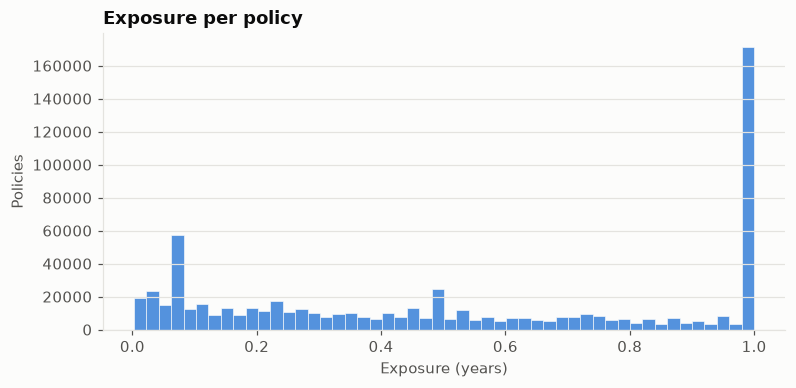

Share with a full year of exposure: 25.0%
Share with under three months:      31.9%


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(policies["Exposure"].to_numpy(), bins=50, color=SERIES[0], alpha=0.8, edgecolor="#fcfcfb", linewidth=0.5)
ax.set_xlabel("Exposure (years)")
ax.set_ylabel("Policies")
ax.set_title("Exposure per policy")
save(fig, "eda_exposure")
plt.show()

print(f"Share with a full year of exposure: {(policies['Exposure'] == 1).mean():.1%}")
print(f"Share with under three months:      {(policies['Exposure'] < 0.25).mean():.1%}")

Only a quarter of policies were on risk for the full year, and nearly a third for under three months. This is why the frequency model needs exposure built in rather than treating each row as one policy-year.

## 5. Claim counts

In [7]:
policies["ClaimNb"].value_counts().sort("ClaimNb").with_columns(
    (pl.col("count") / pl.col("count").sum()).alias("share")
)

ClaimNb,count,share
i64,u32,f64
0,653069,0.9632
1,23571,0.0348
2,1298,0.0019
3,62,0.0001
4,13,0.0000


96% of policies have no claims at all, and multiple claims are rare. A Poisson model suits this kind of data: a small, non-negative count per unit of time.

## 6. Claim amounts

Severity is looked at claim by claim, from the raw severity table, because that is the level a large-loss cap applies at.

In [8]:
amounts = sev_raw["ClaimAmount"].to_numpy()
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999]
pl.DataFrame({"percentile": [f"{q:.1%}" for q in quantiles], "claim amount (EUR)": np.quantile(amounts, quantiles)})

percentile,claim amount (EUR)
str,f64
"""50.0%""",1172.0000
"""75.0%""",1228.0800
"""90.0%""",2799.0720
"""95.0%""",4861.6850
"""99.0%""",16793.7044
"""99.5%""",34386.9871
"""99.9%""",162784.4424


In [9]:
ordered = np.sort(amounts)[::-1]
rows = []
for share in [0.001, 0.005, 0.01, 0.05]:
    n = int(len(ordered) * share)
    rows.append({"largest claims": f"top {share:.1%} ({n} claims)", "share of total cost": ordered[:n].sum() / ordered.sum()})
pl.DataFrame(rows)

largest claims,share of total cost
str,f64
"""top 0.1% (26 claims)""",0.2117
"""top 0.5% (133 claims)""",0.3284
"""top 1.0% (266 claims)""",0.3793
"""top 5.0% (1331 claims)""",0.5211


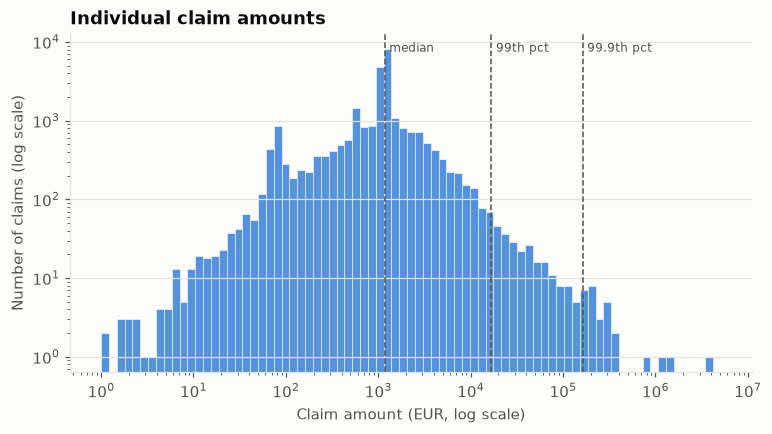

In [10]:
fig = plot_severity_distribution(
    amounts,
    {"median": np.quantile(amounts, 0.5), "99th pct": np.quantile(amounts, 0.99), "99.9th pct": np.quantile(amounts, 0.999)},
)
save(fig, "eda_severity_distribution")
plt.show()

Two things stand out.

**Cost is concentrated in a handful of claims.** The largest 26 claims (0.1%) make up about a fifth of all claim cost, and the single largest claim, EUR 4.1m, is 6.7% on its own. Whether that one claim lands in the training or the test set would move the results noticeably. This is the case for capping large losses before fitting a severity model; the threshold is chosen in the severity notebook.

**There is a spike just above EUR 1,000.** Around 44% of claims sit between EUR 1,100 and EUR 1,300, many at exactly the same amount:

In [11]:
sev_raw.filter(pl.col("ClaimAmount").is_between(1100, 1300))["ClaimAmount"].value_counts().sort(
    "count", descending=True
).head(5)

ClaimAmount,count
f64,u32
1204.0000,4792
1128.1200,3056
1172.0000,2072
1128.0000,831
1228.0800,58


Repeated exact amounts like these usually mean a fixed settlement rather than an assessed cost, for example a flat rate agreed between insurers for standard claims. This is an assumption, as the dataset does not document it. It matters because a large share of severity is then close to constant, and it limits how much any severity model can explain.

## 7. One-way analysis of claim frequency

A one-way chart shows observed claim frequency for each level of a single factor, with the exposure behind each level underneath. Levels with little exposure have noisy observed frequencies and should not be read too closely.

Continuous factors are grouped here only to make the charts readable. The banding used by the GLM is chosen separately, in `pricing.features`.

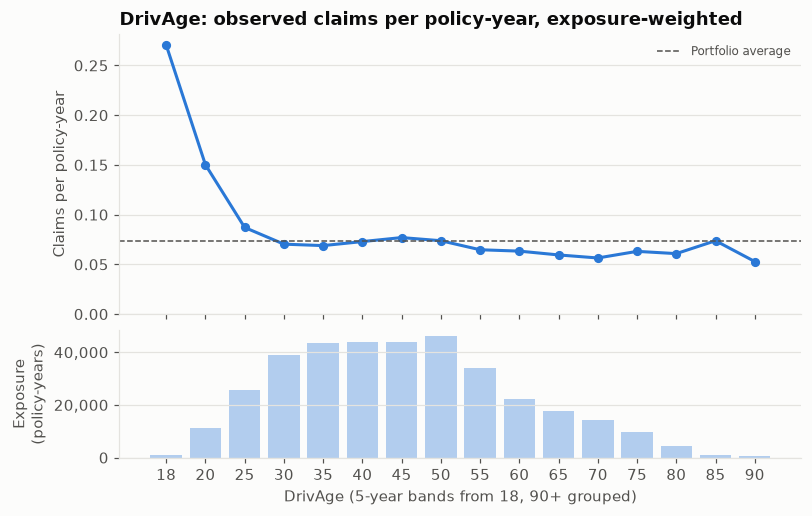

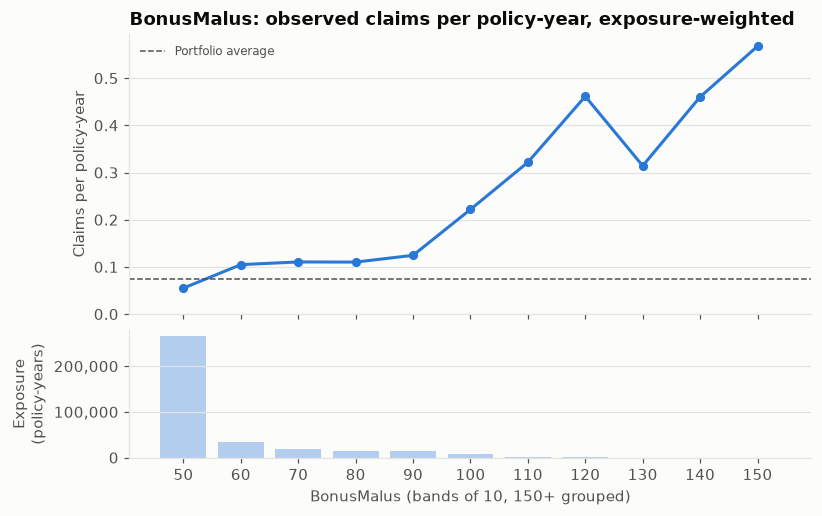

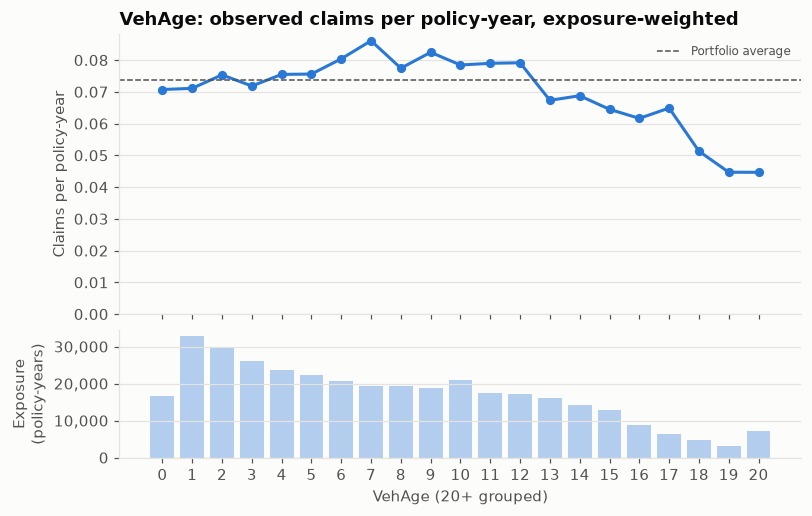

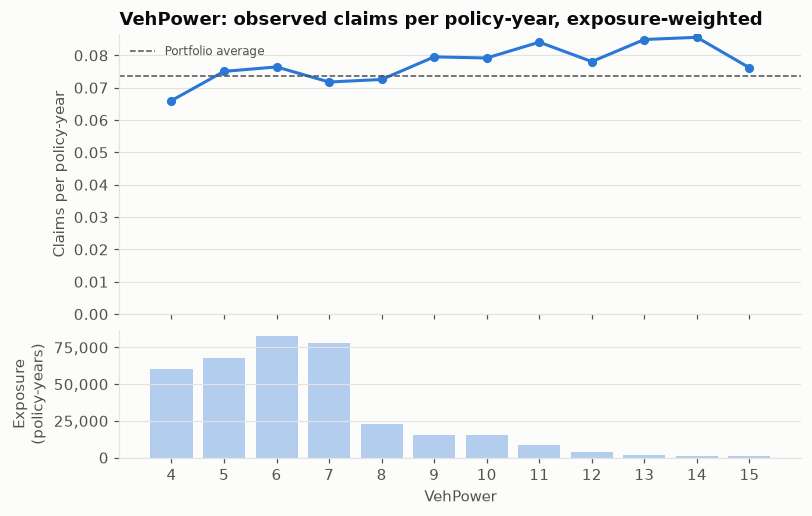

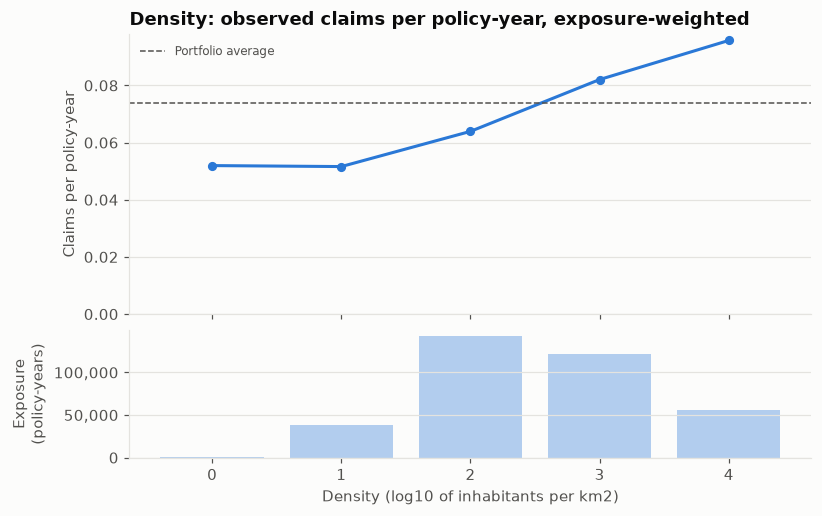

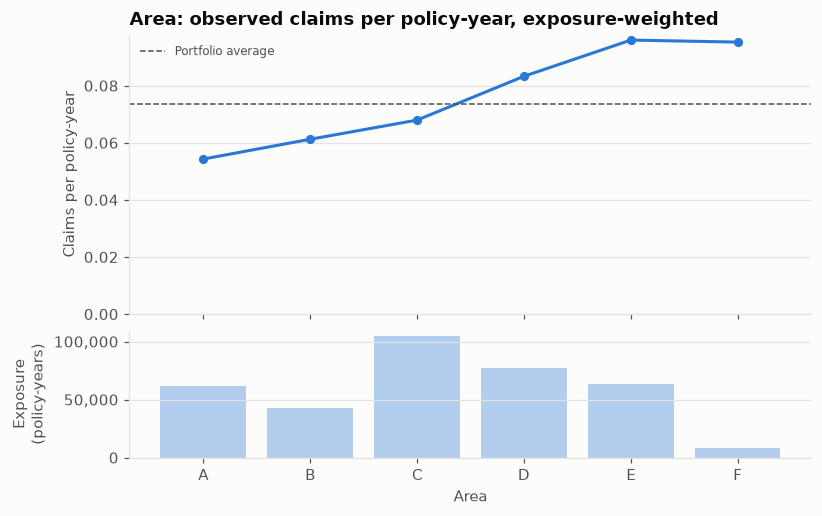

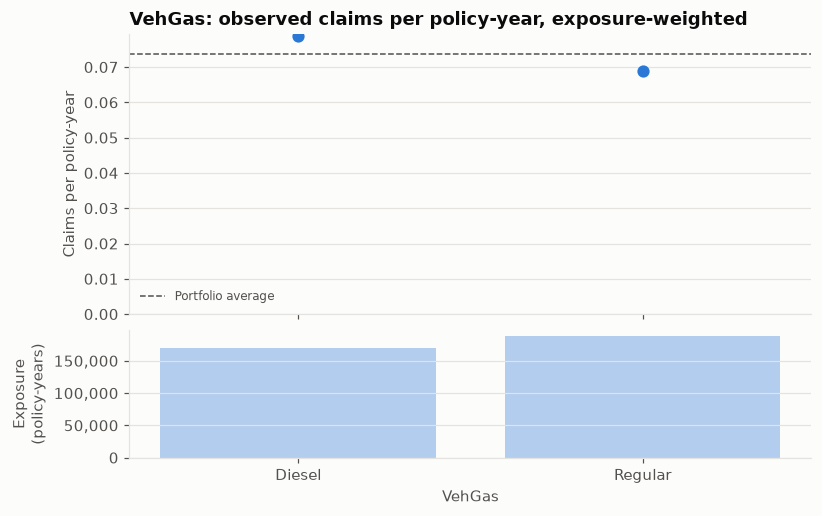

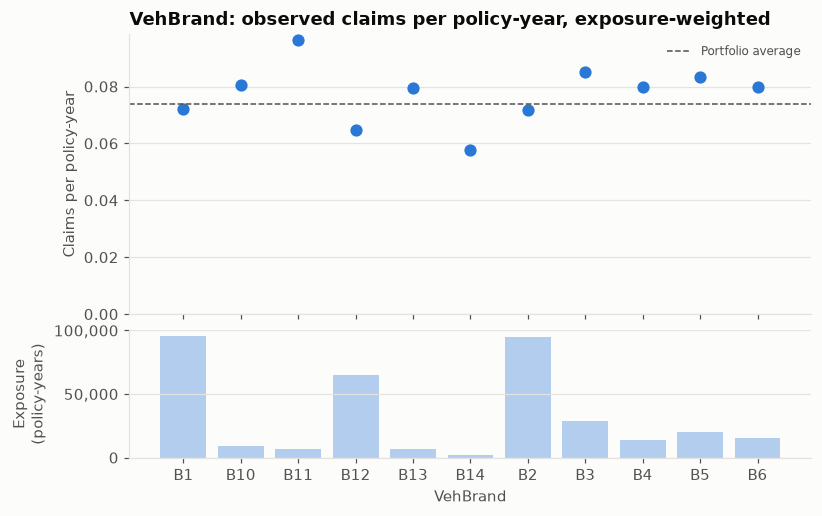

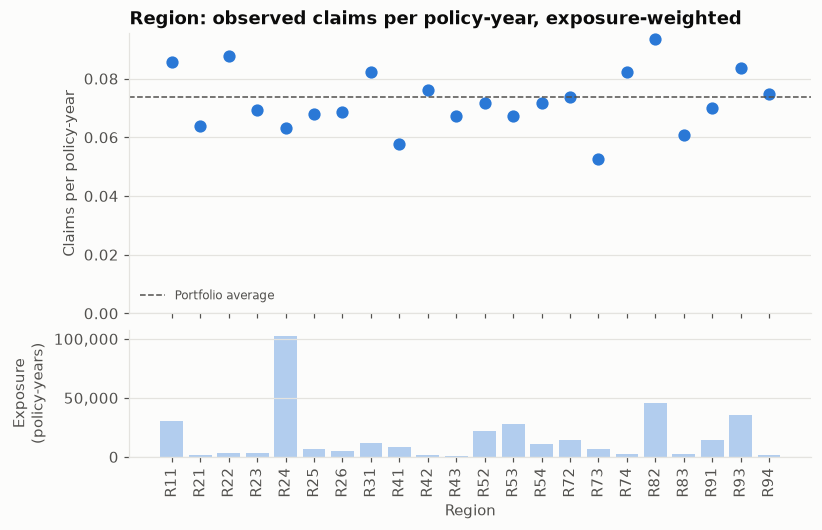

In [12]:
overall = claims / exposure
factors = {
    "DrivAge": ((pl.col("DrivAge").clip(18, 90) // 5 * 5).clip(lower_bound=18), "5-year bands from 18, 90+ grouped"),
    "BonusMalus": (pl.col("BonusMalus").clip(50, 150) // 10 * 10, "bands of 10, 150+ grouped"),
    "VehAge": (pl.col("VehAge").clip(0, 20), "20+ grouped"),
    "VehPower": (pl.col("VehPower"), ""),
    "Density": (pl.col("Density").log10().round(0).cast(pl.Int64), "log10 of inhabitants per km2"),
    "Area": (pl.col("Area"), ""),
    "VehGas": (pl.col("VehGas"), ""),
    "VehBrand": (pl.col("VehBrand"), ""),
    "Region": (pl.col("Region"), ""),
}
tables = {}
for name, (expr, note) in factors.items():
    tables[name] = table = one_way_table(policies, expr, name)
    fig = plot_one_way(
        table, name, overall=overall, rotate_labels=name == "Region",
        ordered=name not in ("VehGas", "VehBrand", "Region"),
    )
    if note:
        fig.axes[1].set_xlabel(f"{name} ({note})")
    save(fig, f"eda_oneway_{name.lower()}")
    plt.show()

What the one-ways show (each read on its own, without adjusting for the other factors):

- **BonusMalus** has the strongest effect. It is the French no-claims system: 50 is the best level, and higher values mean a recent claims history. More than half of policies sit at 50, with a frequency of about 5.5%. Above 100, frequency climbs to 20 to 50%, but on very little exposure.
- **DrivAge** has the familiar young-driver effect. Drivers aged 18 to 19 claim at around 27%, falling to about 7% by 30. There is a mild rise in the late 40s, possibly from young named drivers on a parent's policy, but the data cannot confirm that.
- **Density** and **Area** both show frequency rising with how built-up the area is, from about 5% in the most rural areas to about 9.5% in the densest.
- **VehAge** is fairly flat up to about 12 years and falls after that.
- **VehPower**, **VehGas**, **VehBrand** and **Region** show smaller differences, several of them on thin exposure.

## 8. Factors that overlap

One-ways can mislead when factors are correlated, because one factor's effect shows up in another's chart. Two overlaps matter here.

**Area is a banding of Density.** Each Area letter covers a distinct range of density with no overlap:

In [13]:
policies.group_by("Area").agg(
    pl.col("Density").min().alias("min density"),
    pl.col("Density").max().alias("max density"),
    pl.col("Exposure").sum().alias("exposure"),
).sort("Area")

Area,min density,max density,exposure
str,i64,i64,f64
"""A""",1,50,61956.8277
"""B""",50,100,43001.8239
"""C""",100,500,104402.5238
"""D""",500,1993,77087.8017
"""E""",2001,9850,63785.6943
"""F""",10008,27000,8125.4341


The two carry the same information, so the GLM should use one or the other, not both.

**Young drivers have worse BonusMalus.** A new driver starts at 100 and needs years without a claim to reach 50, so driver age and BonusMalus are strongly linked:

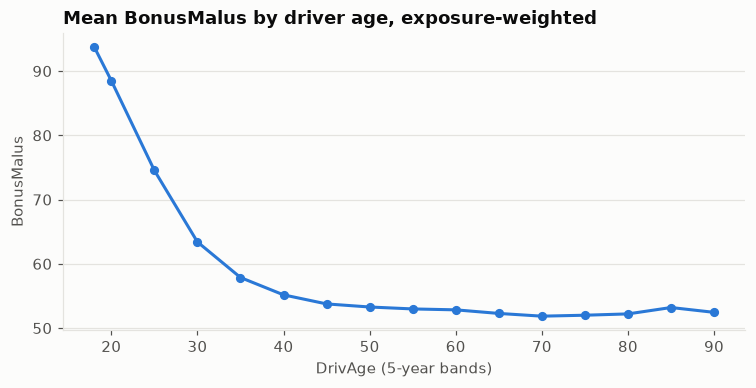

Correlation between DrivAge and BonusMalus: -0.48


In [14]:
by_age = policies.group_by((pl.col("DrivAge").clip(18, 90) // 5 * 5).clip(lower_bound=18)).agg(
    ((pl.col("BonusMalus") * pl.col("Exposure")).sum() / pl.col("Exposure").sum()).alias("mean_bm")
).sort("DrivAge")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(by_age["DrivAge"], by_age["mean_bm"], color=SERIES[0], marker="o")
ax.set_xlabel("DrivAge (5-year bands)")
ax.set_ylabel("BonusMalus")
ax.set_title("Mean BonusMalus by driver age, exposure-weighted")
save(fig, "eda_bonusmalus_by_age")
plt.show()

print(f"Correlation between DrivAge and BonusMalus: {policies.select(pl.corr('DrivAge', 'BonusMalus')).item():.2f}")

Part of the high frequency for young drivers in the one-way is therefore a BonusMalus effect, and the reverse. A GLM fitted on both factors at once separates the two, which is one reason multivariate models are used rather than multiplying one-way relativities together.

## 9. Train/test split

An 80/20 random split by policy with a fixed seed. The test set is not looked at again until the final model comparison. Checking that both halves have similar claim frequency guards against an unlucky split.

In [15]:
train, test = split_train_test(policies)
pl.DataFrame(
    {
        "set": ["train", "test"],
        "policies": [train.height, test.height],
        "exposure": [train["Exposure"].sum(), test["Exposure"].sum()],
        "frequency": [d["ClaimNb"].sum() / d["Exposure"].sum() for d in (train, test)],
    }
)

set,policies,exposure,frequency
str,i64,f64,f64
"""train""",542410,286763.9124,0.0733
"""test""",135603,71596.1931,0.0754


## 10. What this means for the models

- Frequency models need exposure built in, as an offset in the GLM and an equivalent treatment in the GBM, since most policies are on risk for less than a year.
- Large losses must be capped before severity modelling, or a few claims will dominate the fit and the test result.
- The spike of near-fixed claim amounts means severity will be harder to predict than frequency.
- BonusMalus and driver age are expected to be the main frequency drivers, and they overlap, so their one-way effects will shrink once both are in the model.
- Area and Density duplicate each other. The GLM uses banded Density or Area, not both. The GBM can take raw Density.